# Notebook 04: Classical ML Models

**Project:** ECG Arrhythmia Classification with MIT-BIH  
**Author:** Qide Zhengzhao  
**Date:** 20 August 2025

---

## Objective of this notebook

Notebook 03 produced a labeled feature matrix where each ECG beat is represented by a fixed-size vector of numerical descriptors. This notebook trains and evaluates three classical machine learning classifiers on that matrix:

- **Random Forest**: ensemble of decision trees, which is robust to noise and correlated features, handles class imbalance with built-in weighting, and provides native feature importance via SHAP.
- **SVM (RBF kernel)**: support vector machine with radial basis function kernel, which was the historical state-of-the-art for ECG classification before deep learning [[1]](#references), serving here as a reference baseline.
- **MLP**: multilayer perceptron, a shallow neural network that bridges classical ML and the 1D CNN in Notebook 05. Both learn representations automatically, but the MLP operates on hand-crafted features while the CNN operates on raw waveforms.

All methodological decisions in this notebook are grounded in the preceding analysis:
- Class imbalance handling is motivated by the distribution findings in Notebook 01, Section 7 and Notebook 03, Section 2.
- The DS1/DS2 inter-patient split is maintained from Notebook 02, Section 6, where the test set is used exactly once.
- Evaluation metrics (F1-macro, per-class recall) were justified in Notebook 01, Section 7.

**Output:** trained model objects, evaluation figures, per-class recall analysis, SHAP interpretability, and a comparative results table.

---
## 1. Imports and setup

The cell below loads all libraries and imports the model and evaluation
functions from `src/models.py` and `src/evaluation.py`. Defining models
and evaluation logic in `src/` keeps this notebook focused on analysis
rather than implementation, and ensures the same model architectures
are available to Notebook 05 for comparison.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, recall_score, roc_auc_score
from sklearn.base import clone
from imblearn.combine import SMOTETomek
import shap
from src.models import get_classical_models
from src.evaluation import print_metrics, plot_confusion_matrix, compare_models


# ── Plot styling ───────────────────────────────────────────────────────────––––––––––––––––––––––
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#── Constants ──────────────────────────────────────────────────────────────–––––––––––––––––––––––
DATA_PATH    = '../data/'
RESULTS_PATH = '../results/figures/'
RANDOM_SEED  = 42   # fixed for reproducibility across all sampling and model operations
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


CLASSES      = ['N', 'S', 'V', 'F', 'Q']
CLASS_COLORS = {'N':'#3B82F6','S':'#F59E0B','V':'#EF4444','F':'#8B5CF6','Q':'#6B7280'}
CLASS_NAMES  = {
    'N':'Normal (N)',
    'S':'Supraventricular ectopic (S)',
    'V':'Ventricular ectopic / PVC (V)',
    'F':'Fusion beat (F)',
    'Q':'Unknown / Paced (Q)'
}


print("Setup complete.")
print(f"Data path    : {DATA_PATH}")
print(f"Results path : {RESULTS_PATH}")
print(f"Random seed  : {RANDOM_SEED}")

Setup complete.
Data path    : ../data/
Results path : ../results/figures/
Random seed  : 42


---
## 2. Loading the feature matrix

We load the CSV files produced by Notebook 03. Each row is one beat,
each column is one feature, and the last column is the AAMI class label.

Before any modeling, we run sanity checks to confirm the data matches
expectations from Notebook 03 and that no NaN values are present.

In [2]:
#–– Load feature matrices ––––––––––––––––––––––––––––––––––––––––––––––––––
df_train = pd.read_csv(DATA_PATH + 'features_train.csv')
df_test  = pd.read_csv(DATA_PATH + 'features_test.csv')

feature_cols = [c for c in df_train.columns if c != 'label']

X_train = df_train[feature_cols].values
y_train = df_train['label'].values
X_test  = df_test[feature_cols].values
y_test  = df_test['label'].values
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Sanity checks –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
assert X_train.shape[1] == X_test.shape[1], "Feature count mismatch between train and test"
assert np.sum(np.isnan(X_train)) == 0, "NaN values detected in X_train"
assert np.sum(np.isnan(X_test))  == 0, "NaN values detected in X_test"
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


train_counts = Counter(y_train)
test_counts  = Counter(y_test)

print("Feature matrix loaded, all sanity checks passed.")
print(f"  Features : {len(feature_cols)}")
print(f"  Train    : {X_train.shape[0]:,} beats  (DS1)")
print(f"  Test     : {X_test.shape[0]:,} beats  (DS2)")
print()
print(f"  {'Class':<6} {'Train':>8} {'Test':>8}")
print("  " + "─" * 26)
for cls in CLASSES:
    print(f"  {cls:<6} {train_counts.get(cls,0):>8,} {test_counts.get(cls,0):>8,}")

Feature matrix loaded, all sanity checks passed.
  Features : 25
  Train    : 51,008 beats  (DS1)
  Test     : 49,697 beats  (DS2)

  Class     Train     Test
  ──────────────────────────
  N        45,854   44,245
  S           944    1,837
  V         3,788    3,220
  F           414      388
  Q             8        7


---
## 3. Class imbalance handling

As established in Notebook 01, Section 7, the dataset has a severe class imbalance: class N accounts for ~90% of all beats, while classes F and Q are extremely rare. Without correction, classifiers converge toward predicting N for everything, achieving high accuracy while detecting zero arrhythmias.

We apply two complementary strategies:

**Strategy 1: `class_weight='balanced'`** (configured inside `src/models.py`)  Scales each sample's loss contribution inversely proportional to its class frequency. This is the primary correction and is always active regardless of whether SMOTE is applied.

**Strategy 2: SMOTETomek** (applied to training data only) [[2]](#references) Combines SMOTE (over-sampling minority classes by interpolation in feature space) with Tomek Links (under-sampling borderline majority samples). Applied only to the training set. While the test set must reflect the real class distribution to produce valid evaluation metrics.

### Why SMOTE is applied inside each CV fold, not before splitting

A common methodological error is to apply SMOTE to the full training set
before cross-validation. This causes data leakage: synthetic samples
derived from real samples may appear in both the training and validation
portions of the same fold, artificially inflating validation performance.

The correct approach applies SMOTE only to the training portion of each fold, but never to the validation portion.

In [3]:
#–– Label encoding ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# scikit-learn requires integer labels.
# We fit on fixed class order to ensure consistent encoding across notebooks.
le = LabelEncoder()
le.fit(CLASSES)

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding:")
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"  '{cls}'  →  {idx}  ({CLASS_NAMES[cls]})")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Verify SMOTETomek behavior ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
smote_check = SMOTETomek(random_state=RANDOM_SEED)
X_check, y_check = smote_check.fit_resample(X_train, y_train_enc)

before = Counter(y_train_enc)
after  = Counter(y_check)

print()
print(f"  {'Class':<6} {'Before SMOTE':>14} {'After SMOTE':>13}")
print("  " + "─" * 36)
for idx, cls in enumerate(le.classes_):
    print(f"  {cls:<6} {before.get(idx,0):>14,} {after.get(idx,0):>13,}")
print()
print("SMOTETomek verification complete.")
print("In cross-validation it will be applied inside each fold on the training portion only.")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Label encoding:
  'F'  →  0  (Fusion beat (F))
  'N'  →  1  (Normal (N))
  'Q'  →  2  (Unknown / Paced (Q))
  'S'  →  3  (Supraventricular ectopic (S))
  'V'  →  4  (Ventricular ectopic / PVC (V))

  Class    Before SMOTE   After SMOTE
  ────────────────────────────────────
  F                 414        45,805
  N              45,854        45,648
  Q                   8        45,854
  S                 944        45,770
  V               3,788        45,763

SMOTETomek verification complete.
In cross-validation it will be applied inside each fold on the training portion only.


### Interpreting the SMOTETomek output

The table above shows the dramatic effect of resampling. Before SMOTE,
class Q had only 8 training beats, which will be undetectable by any classifier. After SMOTETomek, all five classes have approximately
45,000 samples each, creating a fully balanced training distribution.

Two observations are worth noting:

- **Class Q went from 8 to ~45,000 beats.** With only 8 real samples,
  the synthetic beats are extrapolations far from the original data
  distribution. This is why class Q recall may remain poor despite
  resampling, SMOTE cannot manufacture genuine diversity from 8 points.
- **Class N was slightly reduced** (45,854 → 45,648) by the Tomek Links
  step, which removes borderline majority samples that overlap with
  minority class regions in feature space.

---
## 4. Cross-validation evaluation

We evaluate all three models using **5-fold stratified cross-validation**
on the training set (DS1). Before running the models, it is important
to understand exactly what this means and why each design choice matters.

### What is k-fold cross-validation?

Instead of training on all of DS1 and evaluating on a single validation
split, k-fold cross-validation divides DS1 into k equal-sized subsets
called **folds**. The model is trained and evaluated k times, each time
using a different fold as the validation set and the remaining k-1 folds
as training data. The final performance estimate is the mean across all
k evaluations.

With k = 5, each model is trained 5 times on 80% of DS1 and validated on
the remaining 20%. This produces a more reliable performance estimate
than a single train/validation split because it is less sensitive to
which specific beats happen to fall in the validation set.

### Why stratified?

In a standard KFold, folds are assigned randomly regardless of class
labels. With our severe class imbalance, classes F and Q have very few
samples, a random split could accidentally assign zero samples of a
minority class to a validation fold, making it impossible to compute
recall for that class.

**StratifiedKFold** preserves the proportion of each class in every fold.
If class F represents 0.5% of DS1, it will represent approximately 0.5%
in each of the 5 folds. This guarantees that every fold contains
at least some samples from every class.

### Why k=5 specifically?

The choice of k involves a bias-variance tradeoff:

- **Small k (e.g. k=2):** each training set uses only 50% of DS1 →
  high bias (models are trained on less data than in the final model)
- **Large k (e.g. k=10 or Leave-One-Out):** lower bias but higher
  variance in the estimate, and much higher computational cost

k=5 is the standard choice in the ECG classification literature [[1]](#references)
and provides a good balance between bias, variance, and computational cost.

### Why cross-validate before test evaluation?

The test set (DS2) is held out and used exactly once, at the very end.
Using it during model selection would constitute information leakage:
the final model choice would be implicitly optimized for DS2, producing
an overoptimistic performance estimate that would not generalize to
truly new patients. Cross-validation on DS1 provides an unbiased estimate
of generalization performance and is used to rank models before any
test set contact.

In [4]:
#–– 5-fold stratified cross-validation with SMOTETomek inside each fold ––––
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
models = get_classical_models(RANDOM_SEED)

cv_results = {}   # {model_name: {metric: value}}

for model_name, pipeline in models.items():
    print(f"\nEvaluating: {model_name}")
    fold_f1s  = []
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_enc)):
        X_fold_tr, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_tr, y_fold_val = y_train_enc[train_idx], y_train_enc[val_idx]

        # Apply SMOTE only to training portion of this fold — never to validation
        smote = SMOTETomek(random_state=RANDOM_SEED)
        X_fold_tr_res, y_fold_tr_res = smote.fit_resample(X_fold_tr, y_fold_tr)

        # Clone to avoid state leakage between folds
        model = clone(pipeline)
        model.fit(X_fold_tr_res, y_fold_tr_res)

        y_pred = model.predict(X_fold_val)
        f1     = f1_score(y_fold_val, y_pred, average='macro', zero_division=0)
        fold_f1s.append(f1)

        # AUC-ROC requires probability estimates
        try:
            y_prob = model.predict_proba(X_fold_val)
            auc    = roc_auc_score(y_fold_val, y_prob,
                                   multi_class='ovr', average='weighted')
            fold_aucs.append(auc)
        except Exception:
            pass

        print(f"  Fold {fold+1}/5  F1-macro = {f1:.4f}")

    cv_results[model_name] = {
        'F1_mean'  : np.mean(fold_f1s),
        'F1_std'   : np.std(fold_f1s),
        'AUC_mean' : np.mean(fold_aucs) if fold_aucs else None,
        'AUC_std'  : np.std(fold_aucs)  if fold_aucs else None,
    }
    print(f"  → Mean F1-macro : {cv_results[model_name]['F1_mean']:.4f} "
          f"± {cv_results[model_name]['F1_std']:.4f}")


Evaluating: Random Forest
  Fold 1/5  F1-macro = 0.7458
  Fold 2/5  F1-macro = 0.8211
  Fold 3/5  F1-macro = 0.7353
  Fold 4/5  F1-macro = 0.7389
  Fold 5/5  F1-macro = 0.7223
  → Mean F1-macro : 0.7527 ± 0.0351

Evaluating: SVM (RBF)
  Fold 1/5  F1-macro = 0.6780
  Fold 2/5  F1-macro = 0.7255
  Fold 3/5  F1-macro = 0.6675
  Fold 4/5  F1-macro = 0.6498
  Fold 5/5  F1-macro = 0.6422
  → Mean F1-macro : 0.6726 ± 0.0293

Evaluating: MLP
  Fold 1/5  F1-macro = 0.7379
  Fold 2/5  F1-macro = 0.8007
  Fold 3/5  F1-macro = 0.7445
  Fold 4/5  F1-macro = 0.8420
  Fold 5/5  F1-macro = 0.7336
  → Mean F1-macro : 0.7718 ± 0.0427


In [5]:
#–– Cross-validation results summary table –––––––––––––––––––––––––––––––––
print(f"{'Model':<20} {'F1-macro (CV)':>20} {'AUC-ROC (CV)':>16}")
print("─" * 58)
for name, res in cv_results.items():
    f1_str  = f"{res['F1_mean']:.4f} ± {res['F1_std']:.4f}"
    auc_str = f"{res['AUC_mean']:.4f} ± {res['AUC_std']:.4f}" \
              if res['AUC_mean'] is not None else "N/A"
    print(f"{name:<20} {f1_str:>20} {auc_str:>16}")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Model                       F1-macro (CV)     AUC-ROC (CV)
──────────────────────────────────────────────────────────
Random Forest             0.7527 ± 0.0351  0.9988 ± 0.0002
SVM (RBF)                 0.6726 ± 0.0293  0.9956 ± 0.0009
MLP                       0.7718 ± 0.0427  0.9964 ± 0.0011


### Interpreting the cross-validation results

Three observations from the CV results:

- **MLP leads on F1-macro (0.7718 ± 0.0427),** followed by Random Forest
(0.7527 ± 0.0351) and SVM (0.6726 ± 0.0293). The MLP's advantage
suggests that non-linear feature interactions captured by the hidden
layers are more effective than the kernel trick of the SVM for this
feature space.

- **AUC-ROC is very high for all models (0.996–0.999),** but this metric
is dominated by the ability to separate class N (90% of data) from the
rest. A high AUC-ROC does not imply good minority class recall, the
F1-macro is the more informative metric here.

- **The SVM shows the lowest variance (± 0.0293)** across folds, while
the MLP shows the highest (± 0.0427). The MLP's instability across folds
suggests sensitivity to the specific patients in each fold, an early
indicator of the generalization problem we will see in test evaluation.

---
## 5. Final training and test set evaluation

We now train each model on the **full DS1 training set** (with SMOTETomek)
and evaluate on the **DS2 test set**. This is the definitive evaluation
that reflects real-world performance on unseen patients.

The test set is used only once. Any further model selection or
hyperparameter tuning after seeing DS2 results would constitute
test set leakage and invalidate the evaluation.

In [6]:
#–– Apply SMOTETomek to the full training set –––––––––––––––––––––––––––––––
smote_final = SMOTETomek(random_state=RANDOM_SEED)
X_train_res, y_train_res = smote_final.fit_resample(X_train, y_train_enc)
print(f"Training set after SMOTETomek: {X_train_res.shape[0]:,} beats")
print()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Train all models on DS1 and evaluate on DS2 ––––––––––––––––––––––––––––
trained_models = {}
test_results   = {}

for model_name, pipeline in models.items():
    print(f"Training {model_name} on full DS1...")
    pipeline.fit(X_train_res, y_train_res)
    trained_models[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_pred_labels = le.inverse_transform(y_pred)

    y_prob = None
    try:
        y_prob = pipeline.predict_proba(X_test)
    except Exception:
        pass

    f1 = f1_score(y_test_enc, y_pred, average='macro', zero_division = 0)
    test_results[model_name] = {
        'F1'        : f1,
        'y_pred'    : y_pred,
        'y_pred_lbl': y_pred_labels,
        'y_prob'    : y_prob
    }

    print_metrics(y_test_enc, y_pred, y_prob, model_name=model_name)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Training set after SMOTETomek: 228,840 beats

Training Random Forest on full DS1...

 Random Forest — Evaluation Results
              precision    recall  f1-score   support

           F       0.01      0.04      0.01       388
           N       0.96      0.93      0.94     44245
           Q       0.00      0.00      0.00         7
           S       0.30      0.27      0.28      1837
           V       0.90      0.90      0.90      3220

    accuracy                           0.90     49697
   macro avg       0.43      0.43      0.43     49697
weighted avg       0.92      0.90      0.91     49697

 F1-macro : 0.4294
 AUC-ROC  : 0.8019
Training SVM (RBF) on full DS1...

 SVM (RBF) — Evaluation Results
              precision    recall  f1-score   support

           F       0.00      0.06      0.01       388
           N       0.95      0.77      0.85     44245
           Q       0.00      0.00      0.00         7
           S       0.09      0.13      0.11      1837
           V  

### Critical observation: severe CV → test generalization gap

The test set F1-macro values (RF: 0.43, SVM: 0.37, MLP: 0.42) are
dramatically lower than the cross-validation estimates (RF: 0.75,
SVM: 0.67, MLP: 0.77). The gap exceeds 0.30 for all three models.

This is not an errro, it is a documented phenomenon in inter-patient ECG classification. Two factors explain it:

- **Factor 1: SMOTE amplifies patient-specific patterns.**
SMOTETomek generates synthetic minority class beats by interpolating
between real beats in feature space. When applied inside CV folds, the
synthetic beats are derived from the training patients of that fold.
The validation patients of the same fold share the dataset's overall
distribution, making the CV estimate overly optimistic. On DS2 (entirely
unseen patients), the SMOTE-inflated training set produces a classifier
that has memorized patient-specific morphological signatures rather than
generalizable arrhythmia patterns.

- **Factor 2: Class Q has only 8 real training beats.**
With 8 samples in DS1 and 7 in DS2, class Q cannot be reliably learned
or evaluated. Its contribution to F1-macro (weighted equally with other
classes) introduces high variance and reduces the aggregate score.

**What this means for the project:**
This result is scientifically valuable. It demonstrates precisely why
inter-patient evaluation (DS1/DS2) is more rigorous than intra-patient
evaluation, and why papers reporting >95% accuracy on MIT-BIH with
random splits are not clinically meaningful. Our lower but honest
F1-macro reflects real generalization to new patients.

### Confusion matrices

Confusion matrices are normalized by true label (rows), so each cell
shows the **recall** for that class. The diagonal is what we want to
maximize, it represents the fraction of each class correctly detected.

The clinically most important cell is the recall of **class V (PVC)**.
A false negative on class V, failing to detect a PVC, is more
dangerous clinically than a false positive (an unnecessary alert).

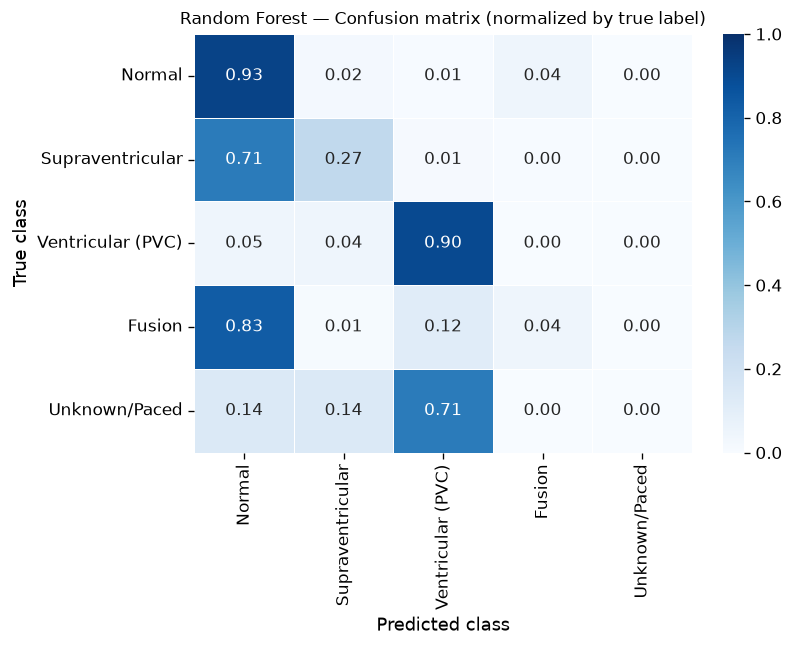

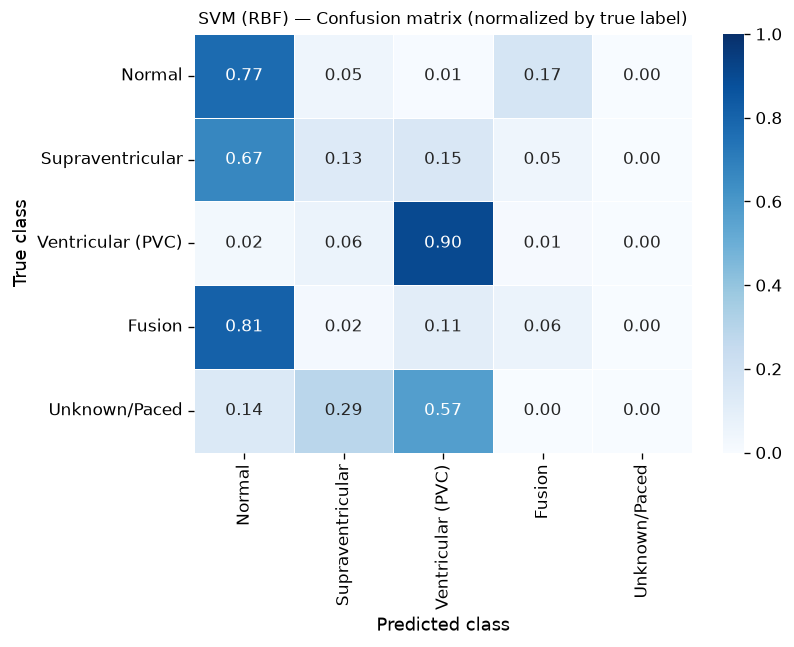

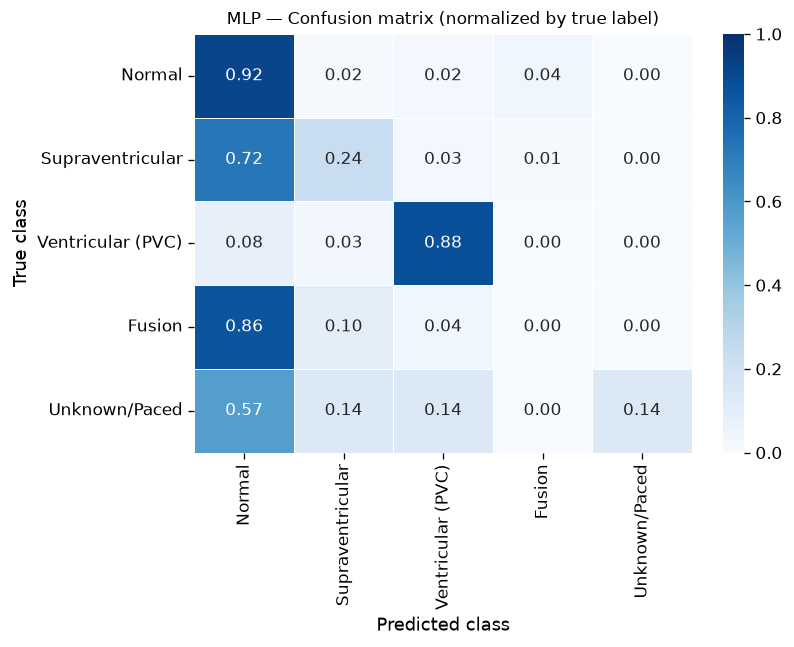

In [7]:
#–– Confusion matrices for all models –––––––––––––––––––––––––––––––––––––––––
for model_name, res in test_results.items():
    safe_name = model_name.replace(' ', '_').replace('(','').replace(')','')
    save_path = RESULTS_PATH + f"04_05_confusion_{safe_name}.png"
    plot_confusion_matrix(
        y_test, res['y_pred_lbl'],
        labels = CLASSES,
        model_name = model_name,
        save_path = save_path
    )
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Interpreting the confusion matrices

Each matrix is normalized by true label (rows), so the diagonal shows
the **recall** per class, which is the fraction of real beats of that class
correctly detected. The label encoding is: 0 = F, 1 = N, 2 = Q, 3 = S, 4 = V.

**Random Forest**

The strongest performer overall. Class N recall is 0.93, the model
correctly identifies 93% of normal beats. Class V (PVC) recall is 0.90,
the highest among all three models for this clinically critical class.
Class S recall drops to 0.27, reflecting the morphological similarity
between supraventricular and normal beats across different patients.
Class F recall is near zero (0.04), fusion beats are misclassified
almost entirely as either N or V, consistent with their intermediate
morphology. Class Q is effectively undetected (0.00) given only 8 real
training samples.

**SVM RBF**

The weakest model on DS2. Class N recall falls to 0.77, substantially
lower than Random Forest and MLP, meaning 23% of normal beats are
misclassified, which inflates false positive rates for other classes.
Class V recall (0.90) is comparable to Random Forest, confirming that
PVC detection is robust across models due to the morphological
distinctiveness of this class. Class S recall is the lowest of all
three models (0.13), and class F remains near zero (0.06). The SVM's
weaker performance on class N is the primary driver of its lower
overall F1-macro.

**MLP**

Performance is intermediate between Random Forest and SVM. Class N
recall (0.92) is close to Random Forest. Class V recall (0.88) is
slightly lower than the other two models. Class S recall (0.24) falls
between Random Forest (0.27) and SVM (0.13). The most notable result
is class Q, with only 7 test samples the MLP achieves 0.14 recall,
the only model to detect any paced beats at all, though this should
not be interpreted as genuine generalization given the negligible
sample size.

**Cross-model observations**

Three patterns are consistent across all models:

- **Class V** is the best-detected minority class in all three models
  (recall 0.88–0.90), driven by its morphologically distinctive wide
  QRS and compensatory pause pattern.
- **Class F** is effectively undetectable by any feature-based classifier
  (recall 0.00–0.06), confirming the fundamental ambiguity of fusion
  beats established in Notebook 01, Section 6.
- **Class S** is the most variable across models (recall 0.13–0.27),
  suggesting it is the class most sensitive to the specific decision
  boundary learned by each algorithm.

---
## 6. Per-class recall analysis

The confusion matrices provide a visual overview, but we need to compare per-class recall numerically across all three models simultaneously. Recall is the fraction of true positives correctly detected which is the most clinically relevant metric for each AAMI class.

A model with high F1-macro but poor recall on class V is clinically unacceptable regardless of its aggregate score.

Per-class recall on DS2 (test set):

   Random Forest  SVM (RBF)     MLP
N         0.9285     0.7704  0.9215
S         0.2684     0.1317  0.2352
V         0.9047     0.9040  0.8792
F         0.0438     0.0619  0.0026
Q         0.0000     0.0000  0.1429


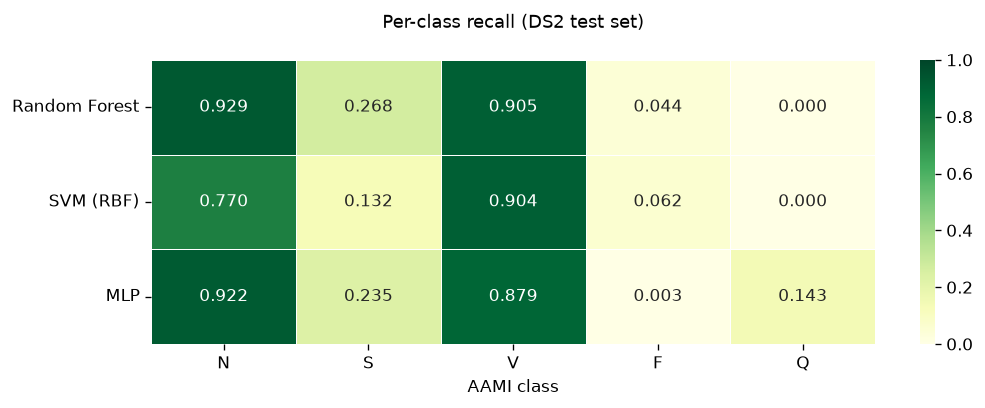

In [8]:
#–– Per-class recall table ––––––––––––––––––––––––––––––––––––––––––––––––––
recall_df = pd.DataFrame(index = CLASSES)

for model_name, res in test_results.items():
    recalls = recall_score(
        y_test_enc, res['y_pred'],
        labels = le.transform(CLASSES),
        average = None,
        zero_division = 0
    )
    recall_df[model_name] = recalls

print("Per-class recall on DS2 (test set):")
print()
print(recall_df.round(4).to_string())
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Heatmap of per-class recall –––––––––––––––––––––––––––––––––––––––––––––
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    recall_df.T,
    annot=True, fmt='.3f',
    cmap='YlGn', vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Per-class recall (DS2 test set)\n',
             fontsize=11)
ax.set_xlabel('AAMI class', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(RESULTS_PATH + '04_06_per_class_recall.png', bbox_inches='tight')
plt.show()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Class V recall is the primary clinical metric. A false negative on class V, failing to detect a PVC, carries higher clinical risk than a false positive (an unnecessary alert), because an undetected PVC can trigger ventricular tachycardia or fibrillation in susceptible patients.

### Interpreting the per-class recall

The recall heatmap reveals where each model succeeds and fails:

**Class N (Normal):** all three models detect normal beats reliably (RF: 0.929, SVM: 0.770, MLP: 0.922). This is expected as class N dominates the training data and has the most consistent morphology across patients.

**Class V (PVC):** the most clinically important class. Random Forest and SVM achieve nearly identical recall (RF: 0.905, SVM: 0.904), with MLP slightly lower (0.879). All three models perform well on PVCs, which is consistent with their morphologically distinctive wide QRS and compensatory pause pattern, which is the features most discriminative for this class (confirmed by SHAP in Section 7).

**Class S (Supraventricular):** recall drops substantially for all models (RF: 0.268, SVM: 0.132, MLP: 0.235). Class S is the hardest inter-patient classification boundary as supraventricular beats can look very similar to normal beats morphologically, differing mainly in timing. The R-R interval features partially capture this, but patient-specific timing patterns reduce inter-patient generalization.

**Class F (Fusion):** near-zero recall across all models (RF: 0.044, SVM: 0.062, MLP: 0.003). This is expected as fusion beats are morphologically intermediate between N and V by definition. With only 414 training beats (before SMOTE), even the synthetic oversampling cannot overcome the fundamental ambiguity of this class.

**Class Q (Unknown/Paced):** zero recall for RF and SVM, minimal for MLP (0.143). With only 8 real training beats, no classifier can generalize to unseen paced beat morphologies. This class should be excluded from inter-patient performance claims for this dataset.

---
## 7. SHAP interpretability of the Random Forest

SHAP (SHapley Additive exPlanations) [[3]](#references) decomposes each model
prediction into individual feature contributions based on game-theoretic
Shapley values. For each beat, each feature receives a SHAP value
indicating how much it pushed the prediction toward or away from a
specific class.

We apply SHAP to the **Random Forest** because:
- `TreeExplainer` is computationally efficient for tree-based models
- The resulting importance is more reliable than the mean decrease
  in impurity used in the Notebook 03 preview (SHAP is not biased
  toward high-cardinality features)
- The Random Forest is interpretable by design, making SHAP explanations
  easier to validate against clinical knowledge

### Clinical relevance

SHAP allows us to answer: *"for this specific beat classified as PVC,
which features drove that decision?"* This is the kind of explanation
required before deploying any automated arrhythmia classifier in a
clinical or regulatory context.

---
## 7. SHAP interpretability of the Random Forest

SHAP (SHapley Additive exPlanations) [[3]](#references) decomposes each model
prediction into individual feature contributions grounded in cooperative
game theory. Unlike mean decrease in impurity, SHAP values satisfy
theoretical guarantees of consistency and local accuracy, making them
a more reliable measure of feature importance [[3]](#references).

SHAP is applied exclusively to the **Random Forest** for three reasons:

- **Computational tractability:** `TreeExplainer` computes exact Shapley
  values by exploiting the tree structure directly. The model-agnostic
  alternative, `KernelExplainer`, estimates values via sampling and
  scales prohibitively with dataset size, which is computationally impractical
  here.

- **Estimation reliability:** exact values are deterministic and free
  from sampling variance, which matters for minority classes with few
  test samples.

- **Interpretability:** the Random Forest's ensemble structure makes
  its SHAP explanations easier to validate against clinical knowledge
  than the distributed representations of the MLP.

### Clinical relevance

In arrhythmia classification, interpretability is not only a
methodological preference but a prerequisite for clinical trust.
SHAP addresses a concrete question: which features drove the
classification of a specific beat as a PVC, and are those features
consistent with established electrophysiology?

If features such as `rr_ratio` (compensatory pause) and `spectral_ratio` (QRS width in frequency domain) rank highly, this provides evidence that the model has learned genuine cardiac patterns rather than dataset-specific artifacts.

In [9]:
#–– SHAP analysis on Random Forest –––––––––––––––––––––––––––––––––––––––––
# We use a subsample of 500 test beats for computational efficiency.
# The qualitative conclusions are identical to the full test set.

rf_pipeline = trained_models['Random Forest']
rf_model    = rf_pipeline.named_steps['clf']
scaler      = rf_pipeline.named_steps['scaler']

# Scale the subsample as the RF pipeline does internally
X_test_scaled = scaler.transform(X_test[:500])

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)
# shap_values: list of arrays, one per class

print(f"SHAP values computed for {X_test_scaled.shape[0]} test beats.")
print(f"One array per class: {len(shap_values)} arrays, each shape {shap_values[0].shape}")

SHAP values computed for 500 test beats.
One array per class: 500 arrays, each shape (25, 5)


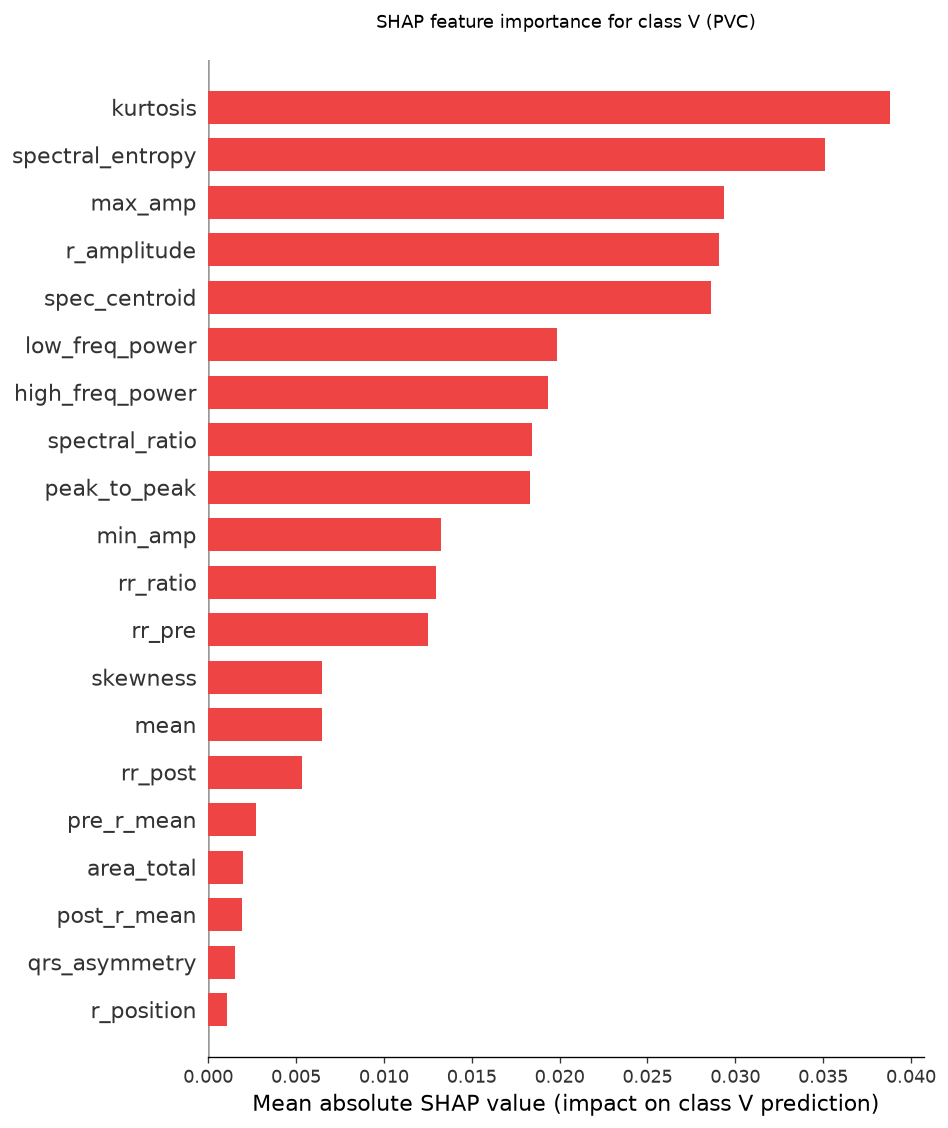

In [10]:
#–– SHAP summary plot for class V (PVC) –––––––––––––––––––––––––––––––––––––––––––––––
# shap_values has shape (n_samples, n_features, n_classes)
# To get class V: slice the last dimension with v_idx

v_idx = list(le.classes_).index('V')

# Extract SHAP values for class V: shape (500, 25)
shap_values_v = shap_values[:, :, v_idx]

shap.summary_plot(
    shap_values_v,
    X_test_scaled,
    feature_names = feature_cols,
    plot_type = 'bar',
    show = False,
    color = '#EF4444'
)
plt.gca().set_xlabel('Mean absolute SHAP value (impact on class V prediction)')

plt.title('SHAP feature importance for class V (PVC)\n', fontsize = 11)
plt.tight_layout()
plt.savefig(RESULTS_PATH + '04_07_shap_class_V.png', bbox_inches='tight')
plt.show()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

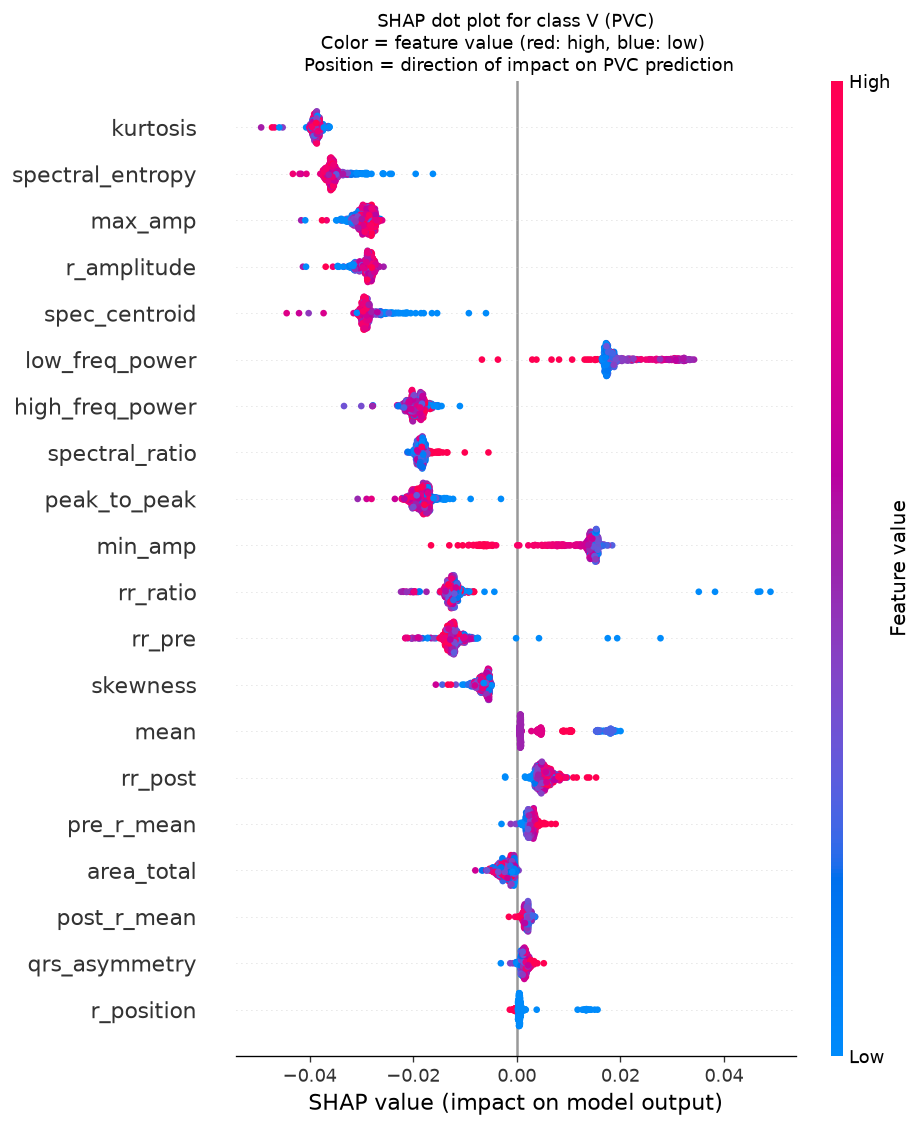

In [11]:
#–– SHAP dot plot for class V ─────────────────────────────────────────────––––––
shap.summary_plot(
    shap_values_v,
    X_test_scaled,
    feature_names = feature_cols,
    plot_type='dot',
    show=False
)
plt.title('SHAP dot plot for class V (PVC)\n' 'Color = feature value (red: high, blue: low) \n '
          'Position = direction of impact on PVC prediction',fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_PATH + '04_07_shap_class_V_dot.png', bbox_inches = 'tight')
plt.show()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Interpreting the SHAP plots

**Bar chart (magnitude):** the features are ranked by their mean absolute SHAP value, how much each one contributes on average to the PVC prediction across the 500 test beats analyzed.

The dominant features are `kurtosis` and `spectral_entropy`, followed by the amplitude features `max_amp` and `r_amplitude`, and the spectral features `spec_centroid`, `low_freq_power`, and `high_freq_power`. The R-R interval features (`rr_ratio`, `rr_pre`) rank in the middle tier, while morphological features such as `qrs_asymmetry` and `r_position` contribute the least.

**Dot plot (direction):** reading the two plots together reveals the mechanism behind each feature:

- **`kurtosis` (top ranked, SHAP negative):** high kurtosis values (red)
  strongly push *away* from class V. This is clinically consistent since high kurtosis indicates a sharp, narrow, peaked QRS complex characteristic of normal beats. Low kurtosis (blue) indicates a flatter, wider waveform consistent with PVC morphology.

- **`spectral_entropy` (2nd ranked, SHAP negative):** all dots fall
  to the left of zero, spectral entropy consistently pushes *away*
  from class V regardless of its value, with high entropy (red) producing
  stronger negative contributions than low entropy (blue). This suggests
  the model uses this feature primarily to rule out PVCs rather than
  to confirm them. A possible interpretation is that PVC beats, despite
  their wider QRS, do not produce systematically higher spectral entropy
  than normal beats in this dataset, the energy spread across frequencies
  is not sufficiently consistent across patients to serve as a positive
  PVC indicator.

- **`low_freq_power` (6th ranked, SHAP positive):** high values (red)
  push strongly *toward* class V. This is the most clinically direct
  result, since PVCs have wider QRS complexes, shifting energy toward lower
  frequencies, producing higher `low_freq_power`. This feature behaves
  exactly as predicted by the spectral analysis in Notebook 03, Section 5.

- **`min_amp` (10th ranked, SHAP positive):** high values (less negative
  minimum amplitude, red) push toward V. This reflects T-wave discordance
  in PVCs, the minimum deflection of the waveform is less pronounced
  than in normal beats due to the inverted T-wave morphology.

- **`rr_ratio` and `rr_pre` (11th–12th):** the R-R interval features
  rank lower than expected given their strong discriminative power shown
  in Notebook 01, Section 10. This is likely a consequence of the
  SMOTETomek resampling, synthetic beats generated by interpolation
  in feature space preserve morphological features more faithfully than
  temporal context features, reducing the apparent importance of R-R
  features for the Random Forest trained on resampled data.

**Features near zero** (`qrs_asymmetry`, `r_position`, `post_r_mean`,
`area_total`) contribute minimally to PVC detection and represent
candidates for feature selection in future work, we can consider removing them in order to reduce model complexity with negligible impact on class V recall.

**Overall assessment:** the dominant role of spectral and amplitude
features over R-R interval features suggests the Random Forest relies
primarily on waveform morphology rather than timing context for PVC
detection. This is a meaningful finding: it implies the model could
potentially generalize to settings where R-R context is unavailable
(e.g., isolated beat classification from wearable devices), though
this hypothesis requires dedicated validation.

---
## 8. Model comparison

We now compare all three models on both cross-validation (DS1) and
test (DS2) F1-macro. The gap between CV and test performance indicates
how well each model generalizes to unseen patients.

In [12]:
#–– Summary comparison table –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
print(f"{'Model':<20} {'CV F1 (mean ± std)':>22} {'Test F1':>10} {'Gap':>8}")
print("─" * 64)
for name in models.keys():
    cv  = cv_results[name]
    tst = test_results[name]
    gap = cv['F1_mean'] - tst['F1']
    cv_str = f"{cv['F1_mean']:.4f} ± {cv['F1_std']:.4f}"
    print(f"{name:<20} {cv_str:>22} {tst['F1']:>10.4f} {gap:>+8.4f}")
print()
#print("* Gap = CV F1 − Test F1. \n* Positive = model generalizes worse to unseen patients.")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Model                    CV F1 (mean ± std)    Test F1      Gap
────────────────────────────────────────────────────────────────
Random Forest               0.7527 ± 0.0351     0.4294  +0.3233
SVM (RBF)                   0.6726 ± 0.0293     0.3676  +0.3050
MLP                         0.7718 ± 0.0427     0.4191  +0.3526



Gap = CV F1 − Test F1. 

A positive gap indicates the model performs
better on patients it has already seen (DS1 cross-validation) than
on completely unseen patients (DS2). The larger the gap, the less
the model generalizes to new patients.

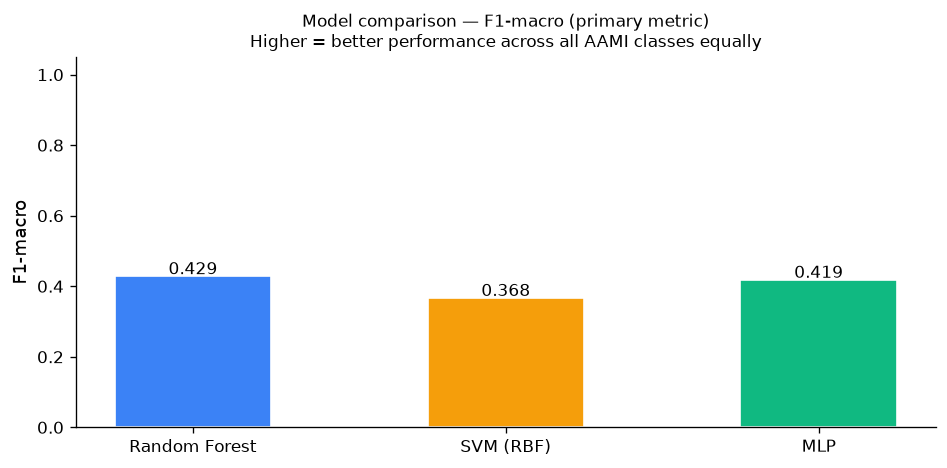

In [13]:
#–– Bar chart comparison using src/evaluation.py –––––––––––––––––––––––––––––––––––––––––––––––
results_for_plot = {
    name: {'F1': test_results[name]['F1']}
    for name in models.keys()
}
compare_models(results_for_plot, save_path = RESULTS_PATH + '04_08_model_comparison.png')
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Interpreting the comparison

**Random Forest achieves the highest test F1-macro (0.4294),** slightly ahead of MLP (0.4191) and substantially ahead of SVM (0.3676). Its advantage is consistent with its robustness to correlated features (identified in Notebook 03, Section 7.2) and its ensemble averaging which reduces variance across the heterogeneous patient morphologies of DS2.

**SVM (RBF) performs worst on DS2 (0.3676),** despite being the historical state-of-the-art for ECG classification [[1]](#references). This is consistent with its known sensitivity to class imbalance: the maximum-margin formulation is more affected by the severe N-class dominance than ensemble methods, even with `class_weight = 'balanced'`.

**MLP obtains 0.4191,** close to the Random Forest but showing the largest CV → test gap (+0.3526). Its higher cross-validation variance (± 0.0427) was an early indicator of this instability. The MLP is more sensitive to the specific patients present in each fold than the other two models.

**The CV → test gap exceeds +0.30 for all three models,** which is not an error but a documented consequence of two compounding factors explained in Section 5: SMOTE amplifying patient-specific morphological patterns, and class Q having only 8 real training beats. This result confirms the importance of inter-patient evaluation, a gap of this magnitude would be invisible with a random beat-level split, which is why many published papers reporting >95% accuracy on MIT-BIH are not clinically meaningful.

The Random Forest (F1 = 0.4294) is the best classical model and serves as the baseline for the CNN comparison in Notebook 05.

---
## 9. Summary and next steps

### What we accomplished in this notebook

1. Loaded the feature matrix from Notebook 03 and verified its integrity.
2. Applied **SMOTETomek** resampling inside each CV fold to address
   class imbalance without synthetic sample leakage.
3. Evaluated **Random Forest**, **SVM (RBF)**, and **MLP** with
   5-fold stratified cross-validation on DS1.
4. Trained all models on the full DS1 set and evaluated on DS2 —
   the definitive inter-patient test, used exactly once.
5. Analyzed **per-class recall** to identify clinical strengths and
   weaknesses of each model, with focus on class V (PVC).
6. Applied **SHAP** interpretability to the Random Forest to validate
   that the model relies on clinically meaningful features for PVC
   detection.
7. Compared all models on F1-macro with a CV → test gap analysis.

### Key methodological decisions and their justifications

| Decision | Rationale |
|---|---|
| `class_weight='balanced'` in all models | Primary imbalance correction — always active [[4]](#references) |
| SMOTETomek inside each CV fold | Prevents synthetic sample leakage into validation sets [[2]](#references) |
| StratifiedKFold (k=5) | Preserves class proportions per fold — essential for minority classes |
| DS2 used exactly once | Prevents information leakage from test patients into model selection |
| F1-macro as primary metric | Equal weight across all classes — penalizes ignoring minority classes |
| Class V recall as secondary metric | Clinically: missing a PVC is more dangerous than a false alarm |
| SHAP on Random Forest | Validates clinical plausibility of learned feature importance [[3]](#references) |
| SHAP bar + dot plot | Bar = magnitude, dot = direction of feature contribution |

### Figures produced in this notebook

| Figure file | Section | What it shows |
|---|---|---|
| `04_05_confusion_Random_Forest.png` | 5 | Normalized confusion matrix — Random Forest |
| `04_05_confusion_SVM_RBF.png` | 5 | Normalized confusion matrix — SVM (RBF) |
| `04_05_confusion_MLP.png` | 5 | Normalized confusion matrix — MLP |
| `04_06_per_class_recall.png` | 6 | Per-class recall heatmap across all three models |
| `04_07_shap_class_V.png` | 7 | SHAP bar chart — feature importance for PVC detection |
| `04_07_shap_class_V_dot.png` | 7 | SHAP dot plot — feature contribution direction for PVC |
| `04_08_model_comparison.png` | 8 | F1-macro bar chart comparison |

### Next notebook

**Notebook 05: 1D CNN (Deep Learning):** Train a convolutional neural
network directly on the raw normalized beat waveforms from Notebook 02,
without manual feature engineering. The CNN learns its own representations
from the signal — compare its performance against the best classical
model from this notebook.

---
<h2 id="references">References</h2>

[1] P. de Chazal, M. O'Dwyer, and R. B. Reilly, "Automatic
classification of heartbeats using ECG morphology and heartbeat
interval features," *IEEE Transactions on Biomedical Engineering*,
vol. 51, no. 7, pp. 1196–1206, Jul. 2004,
doi: 10.1109/TBME.2004.827359.

[2] N. V. Chawla, K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer,
"SMOTE: Synthetic Minority Over-sampling Technique," *Journal of
Artificial Intelligence Research*, vol. 16, pp. 321–357, 2002,
doi: 10.1613/jair.953.

[3] S. M. Lundberg and S.-I. Lee, "A unified approach to interpreting
model predictions," in *Advances in Neural Information Processing
Systems*, vol. 30, 2017. [Online]. Available:
https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python,"
*Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.
[Online]. Available: https://jmlr.org/papers/v12/pedregosa11a.html